# GDV – Goal Build-up Analysis FIFA World Cup 2022

## Research question

How are goals created at the FIFA World Cup 2022: through quick attacks with few passes or through longer passing sequences?

In addition, this analysis explores whether a team’s goal build-up style relates to finishing efficiency and tournament progress.

## Use case

A coach, analyst or football fan wants to understand how goals are created. The focus is not only on who scored, but on how the ball was moved before the goal.

The analysis answers the following questions:

1. How many successful passes happen before a goal?
2. Are goals more often created through quick, medium or long build-ups?
3. Which teams score after more direct attacks and which teams score after longer passing sequences?
4. Are more passes before a goal also linked to longer attack duration?
5. Is there a visible relationship between finishing efficiency and tournament progress?
6. What does a concrete Spain goal build-up look like as a case study?

## Dataset

The analysis uses StatsBomb Open Data for the FIFA World Cup 2022. The data contains event-level football actions such as passes, shots, goals, possessions and pitch coordinates.

For each goal, the same possession phase is analysed. Within this possession, successful passes before the goal are counted.

## Limitation

The analysis is based on event data, not tracking data. This means that the ball actions are visible, but not the full movement of all players.

## 1. Setup

This section loads the required Python packages and defines the project paths. The output figures are saved in `reports/figures`, and the processed data is saved in `data/processed`.

In [1]:
from pathlib import Path
import ast
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GOAL_BUILDUPS_FILE = PROCESSED_DIR / "goal_buildups.csv"
GOAL_PASSES_FILE = PROCESSED_DIR / "goal_buildup_passes.csv"

COMPETITION_ID = 43
SEASON_ID = 106

print(PROJECT_ROOT)

c:\Users\emirc\Football


## 2. Helper functions

StatsBomb stores pitch locations as coordinate pairs. These helper functions extract x- and y-coordinates and calculate event time in seconds.

In [2]:
def parse_location(value):
    if isinstance(value, list) and len(value) >= 2:
        return value

    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list) and len(parsed) >= 2:
                return parsed
        except Exception:
            return None

    return None


def get_x(value):
    loc = parse_location(value)
    if isinstance(loc, list):
        return loc[0]
    return np.nan


def get_y(value):
    loc = parse_location(value)
    if isinstance(loc, list):
        return loc[1]
    return np.nan


def seconds_total(row):
    minute = int(row["minute"])
    second = int(row["second"]) if not pd.isna(row["second"]) else 0
    return minute * 60 + second

## 3. Data preprocessing

For each goal, I identify the possession that directly led to the goal. Then I count all successful passes by the scoring team within the same possession before the shot.

This follows the project logic: if possession changes or an interruption occurs, a new possession starts and the build-up sequence also starts again.

In [3]:
def build_goal_sequences(force_rebuild=False):
    if GOAL_BUILDUPS_FILE.exists() and GOAL_PASSES_FILE.exists() and not force_rebuild:
        buildups = pd.read_csv(GOAL_BUILDUPS_FILE)
        passes = pd.read_csv(GOAL_PASSES_FILE)
        return buildups, passes

    matches = sb.matches(
        competition_id=COMPETITION_ID,
        season_id=SEASON_ID
    )

    all_buildups = []
    all_passes = []

    for match_idx, match in matches.reset_index(drop=True).iterrows():
        match_id = int(match["match_id"])
        home_team = match["home_team"]
        away_team = match["away_team"]
        match_label = f"{home_team} vs {away_team}"

        print(f"{match_idx + 1}/{len(matches)} {match_label}")

        try:
            events = sb.events(match_id=match_id)
        except Exception as exc:
            print(f"Match {match_id} konnte nicht geladen werden: {exc}")
            continue

        needed_columns = [
            "id",
            "index",
            "period",
            "timestamp",
            "minute",
            "second",
            "team",
            "player",
            "type",
            "possession",
            "location",
            "pass_end_location",
            "pass_outcome",
            "shot_outcome",
            "play_pattern"
        ]

        for col in needed_columns:
            if col not in events.columns:
                events[col] = np.nan

        events = events.sort_values(["period", "index"]).copy()

        events["event_seconds"] = events.apply(seconds_total, axis=1)
        events["x"] = events["location"].apply(get_x)
        events["y"] = events["location"].apply(get_y)
        events["end_x"] = events["pass_end_location"].apply(get_x)
        events["end_y"] = events["pass_end_location"].apply(get_y)

        goals = events[
            (events["type"] == "Shot")
            & (events["shot_outcome"].astype(str).str.lower() == "goal")
        ].copy()

        for goal_number, goal in goals.reset_index(drop=True).iterrows():
            team = goal["team"]
            possession = goal["possession"]
            goal_index = goal["index"]
            goal_seconds = goal["event_seconds"]
            build_up_id = f"{match_id}_{goal_number + 1}"

            same_possession = events[
                (events["possession"] == possession)
                & (events["team"] == team)
                & (events["index"] <= goal_index)
            ].copy()

            if same_possession.empty:
                continue

            successful_passes = same_possession[
                (same_possession["type"] == "Pass")
                & (
                    same_possession["pass_outcome"].isna()
                    | (same_possession["pass_outcome"].astype(str).str.lower() == "nan")
                )
            ].copy()

            if successful_passes.empty:
                first_event = same_possession.iloc[0]
                start_x = first_event["x"]
                start_y = first_event["y"]
                start_seconds = first_event["event_seconds"]
            else:
                first_pass = successful_passes.iloc[0]
                start_x = first_pass["x"]
                start_y = first_pass["y"]
                start_seconds = first_pass["event_seconds"]

            duration_seconds = max(0, goal_seconds - start_seconds)

            all_buildups.append(
                {
                    "build_up_id": build_up_id,
                    "match_id": match_id,
                    "match_date": match.get("match_date"),
                    "match_label": match_label,
                    "team": team,
                    "goal_player": goal.get("player"),
                    "goal_minute": goal.get("minute"),
                    "goal_second": goal.get("second"),
                    "period": goal.get("period"),
                    "possession": possession,
                    "play_pattern": goal.get("play_pattern"),
                    "passes_before_goal": len(successful_passes),
                    "duration_seconds": duration_seconds,
                    "start_x": start_x,
                    "start_y": start_y,
                    "goal_x": goal.get("x"),
                    "goal_y": goal.get("y")
                }
            )

            for pass_order, p in successful_passes.reset_index(drop=True).iterrows():
                all_passes.append(
                    {
                        "build_up_id": build_up_id,
                        "match_id": match_id,
                        "match_label": match_label,
                        "team": team,
                        "goal_player": goal.get("player"),
                        "goal_minute": goal.get("minute"),
                        "pass_order": pass_order + 1,
                        "player": p.get("player"),
                        "minute": p.get("minute"),
                        "second": p.get("second"),
                        "x": p.get("x"),
                        "y": p.get("y"),
                        "end_x": p.get("end_x"),
                        "end_y": p.get("end_y")
                    }
                )

        time.sleep(0.1)

    buildups = pd.DataFrame(all_buildups)
    passes = pd.DataFrame(all_passes)

    buildups.to_csv(GOAL_BUILDUPS_FILE, index=False)
    passes.to_csv(GOAL_PASSES_FILE, index=False)

    return buildups, passes

## 4. Load or create the goal build-up dataset

The processed dataset contains one row per goal and one row per successful pass in goal build-ups. If the CSV files already exist, they are loaded directly. Otherwise, they are created from the StatsBomb event data.

In [4]:
buildups, passes = build_goal_sequences(force_rebuild=False)

print("Goals analysed:", len(buildups))
print("Passes before goals:", len(passes))
print("Teams:", buildups["team"].nunique())

display(buildups.head())
display(passes.head())

Goals analysed: 195
Passes before goals: 1097
Teams: 32


,build_up_id,match_id,match_date,match_label,team,goal_player,goal_minute,goal_second,period,possession,play_pattern,passes_before_goal,duration_seconds,start_x,start_y,goal_x,goal_y
0,3857256_1,3857256,2022-12-02,Serbia vs Switzerland,Switzerland,Xherdan Shaqiri,19,11,1,44,From Free Kick,5,18,29.7,74.2,107.5,50.6
1,3857256_2,3857256,2022-12-02,Serbia vs Switzerland,Serbia,Aleksandar Mitrović,25,56,1,68,Regular Play,2,7,57.3,13.5,108.3,38.6
2,3857256_3,3857256,2022-12-02,Serbia vs Switzerland,Serbia,Dušan Vlahović,34,28,1,82,From Counter,0,5,80.8,20.3,106.2,31.8
3,3857256_4,3857256,2022-12-02,Serbia vs Switzerland,Switzerland,Breel-Donald Embolo,43,41,1,99,Regular Play,5,19,6.4,53.0,114.4,36.9
4,3857256_5,3857256,2022-12-02,Serbia vs Switzerland,Switzerland,Remo Freuler,47,38,2,113,From Free Kick,9,34,49.4,25.9,107.2,41.2


,build_up_id,match_id,match_label,team,goal_player,goal_minute,pass_order,player,minute,second,x,y,end_x,end_y
0,3857256_1,3857256,Serbia vs Switzerland,Switzerland,Xherdan Shaqiri,19,1,Silvan Widmer,18,53,29.7,74.2,22.9,29.1
1,3857256_1,3857256,Serbia vs Switzerland,Switzerland,Xherdan Shaqiri,19,2,Manuel Obafemi Akanji,18,55,23.1,29.7,46.3,13.4
2,3857256_1,3857256,Serbia vs Switzerland,Switzerland,Xherdan Shaqiri,19,3,Ricardo Iván Rodríguez Araya,18,59,46.3,14.0,66.2,5.6
3,3857256_1,3857256,Serbia vs Switzerland,Switzerland,Xherdan Shaqiri,19,4,Ruben Vargas,19,1,66.2,5.6,89.1,11.8
4,3857256_1,3857256,Serbia vs Switzerland,Switzerland,Xherdan Shaqiri,19,5,Djibril Sow,19,10,107.0,44.5,108.0,52.0


## 5. Build-up categories

To make the analysis easier to interpret, goals are grouped into three build-up types:

- Quick: 0 to 3 successful passes before the goal
- Medium: 4 to 7 successful passes before the goal
- Long: 8 or more successful passes before the goal

In [5]:
def classify_buildup(pass_count):
    if pass_count <= 3:
        return "Quick"
    if pass_count <= 7:
        return "Medium"
    return "Long"


buildups = buildups.copy()
passes = passes.copy()

buildups["build_up_type"] = buildups["passes_before_goal"].apply(classify_buildup)

if "build_up_type" in passes.columns:
    passes = passes.drop(columns=["build_up_type"])

passes = passes.merge(
    buildups[["build_up_id", "build_up_type"]],
    on="build_up_id",
    how="left"
)

display(buildups["build_up_type"].value_counts())
display(buildups[["passes_before_goal", "duration_seconds"]].describe())

build_up_type
Quick     97
Medium    51
Long      47
Name: count, dtype: int64

,passes_before_goal,duration_seconds
count,195.000000,195.000000
mean,5.625641,18.641026
std,7.192376,22.827781
min,0.000000,0.000000
25%,0.000000,1.000000
50%,4.000000,11.000000
75%,7.000000,26.500000
max,35.000000,106.000000


## 6. Pitch drawing function

The following function draws a simple football pitch using the StatsBomb coordinate system. It is used for the spatial visualizations and the Spain case study.

In [6]:
def draw_pitch(ax):
    ax.plot([0, 120], [0, 0], color="black", linewidth=1)
    ax.plot([0, 120], [80, 80], color="black", linewidth=1)
    ax.plot([0, 0], [0, 80], color="black", linewidth=1)
    ax.plot([120, 120], [0, 80], color="black", linewidth=1)

    ax.plot([60, 60], [0, 80], color="black", linewidth=1)
    ax.add_patch(plt.Circle((60, 40), 10, fill=False, color="black", linewidth=1))

    ax.plot([0, 18], [18, 18], color="black", linewidth=1)
    ax.plot([18, 18], [18, 62], color="black", linewidth=1)
    ax.plot([18, 0], [62, 62], color="black", linewidth=1)

    ax.plot([120, 102], [18, 18], color="black", linewidth=1)
    ax.plot([102, 102], [18, 62], color="black", linewidth=1)
    ax.plot([102, 120], [62, 62], color="black", linewidth=1)

    ax.set_xlim(0, 120)
    ax.set_ylim(80, 0)
    ax.set_aspect("equal")
    ax.axis("off")

## 7. Static visual analysis

The following figures answer the main research question step by step. The goal is not to create many plots, but to build a clear argument about how goals are created.

### Figure 1: Passes before goals

This histogram shows the distribution of successful passes before goals. It directly answers whether goals are usually created after few passes or after longer passing sequences.

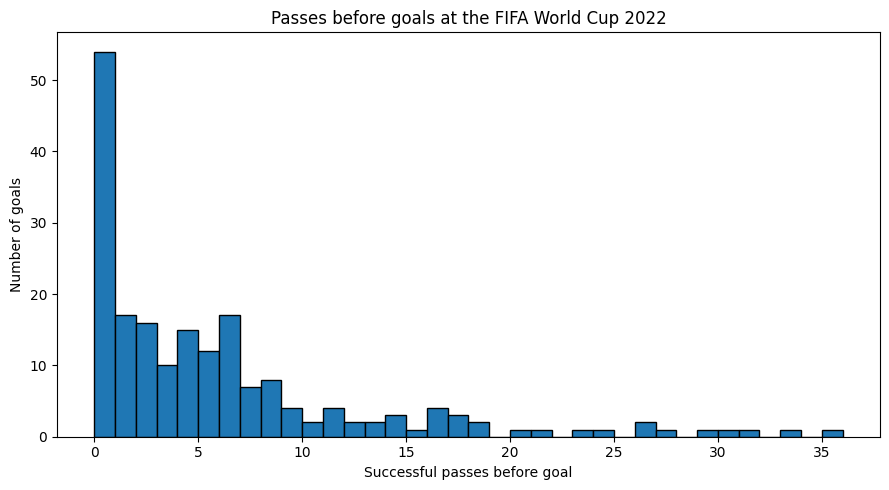

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

max_passes = int(buildups["passes_before_goal"].max())

ax.hist(
    buildups["passes_before_goal"],
    bins=range(0, max_passes + 2),
    edgecolor="black"
)

ax.set_title("Passes before goals at the FIFA World Cup 2022")
ax.set_xlabel("Successful passes before goal")
ax.set_ylabel("Number of goals")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig01_passes_before_goals.png", dpi=300, bbox_inches="tight")
plt.show()

The histogram is useful for exploration because it shows the full distribution. However, for communication it is still quite detailed. Therefore, the next figure groups goals into quick, medium and long build-ups.

### Figure 2: Build-up types

This figure simplifies the distribution into three categories. It makes the main pattern easier to read than the histogram.

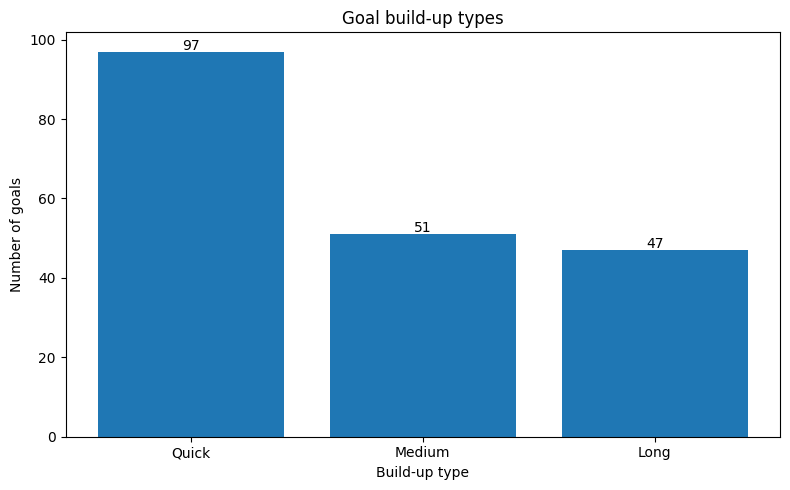

build_up_type
Quick     97
Medium    51
Long      47
Name: count, dtype: int64

In [8]:
build_up_counts = (
    buildups["build_up_type"]
    .value_counts()
    .reindex(["Quick", "Medium", "Long"])
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    build_up_counts.index,
    build_up_counts.values
)

ax.set_title("Goal build-up types")
ax.set_xlabel("Build-up type")
ax.set_ylabel("Number of goals")

for i, value in enumerate(build_up_counts.values):
    ax.text(i, value + 0.5, str(int(value)), ha="center")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig02_buildup_types.png", dpi=300, bbox_inches="tight")
plt.show()

display(build_up_counts)

### Figure 3: Team comparison

This figure compares the average number of passes before goals by team. Teams with lower values score more directly, while teams with higher values score after longer passing sequences.

Only teams with at least two goals are included to reduce the effect of single-goal outliers.

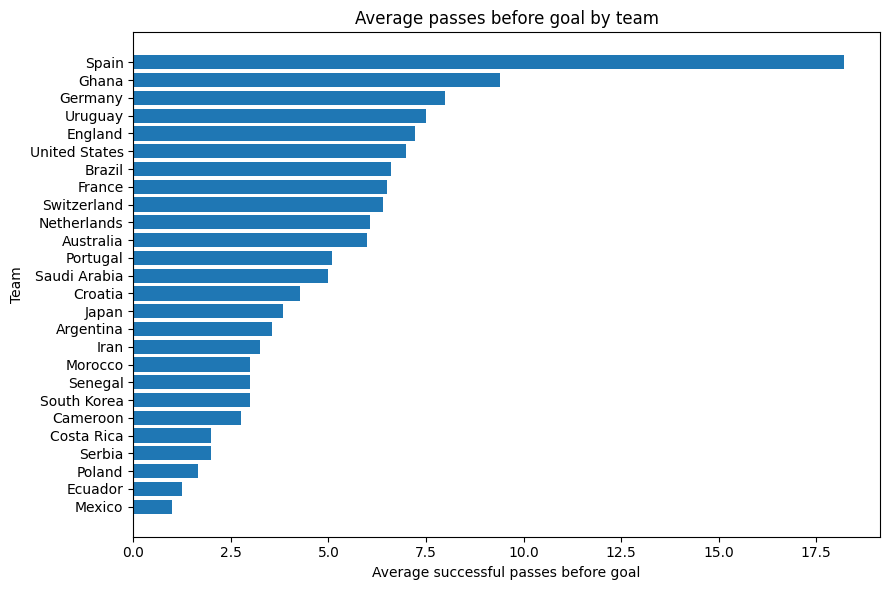

,team,goals,avg_passes,median_passes,avg_duration
16,Mexico,2,1.000000,1.0,1.000000
9,Ecuador,4,1.250000,1.5,2.750000
19,Poland,3,1.666667,0.0,9.000000
24,Serbia,5,2.000000,2.0,7.000000
6,Costa Rica,2,2.000000,2.0,5.500000
4,Cameroon,4,2.750000,3.0,9.750000
25,South Korea,5,3.000000,1.0,12.600000
23,Senegal,5,3.000000,1.0,11.000000
17,Morocco,9,3.000000,1.0,10.888889
14,Iran,4,3.250000,3.5,16.000000


In [9]:
team_goal_summary = (
    buildups.groupby("team")
    .agg(
        goals=("build_up_id", "count"),
        avg_passes=("passes_before_goal", "mean"),
        median_passes=("passes_before_goal", "median"),
        avg_duration=("duration_seconds", "mean")
    )
    .reset_index()
)

team_goal_summary_filtered = (
    team_goal_summary[team_goal_summary["goals"] >= 2]
    .sort_values("avg_passes", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    team_goal_summary_filtered["team"],
    team_goal_summary_filtered["avg_passes"]
)

ax.set_title("Average passes before goal by team")
ax.set_xlabel("Average successful passes before goal")
ax.set_ylabel("Team")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig03_avg_passes_by_team.png", dpi=300, bbox_inches="tight")
plt.show()

display(team_goal_summary_filtered)

### Figure 4: Passes and attack duration

This scatterplot checks whether more passes before a goal also mean a longer attack duration. This is important because pass count alone does not fully describe the speed of an attack.

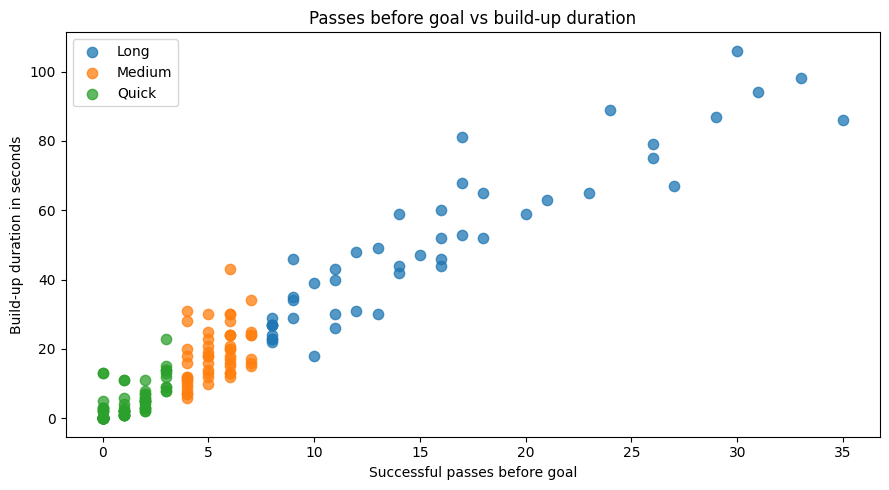

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for build_type, group in buildups.groupby("build_up_type"):
    ax.scatter(
        group["passes_before_goal"],
        group["duration_seconds"],
        label=build_type,
        alpha=0.75,
        s=55
    )

ax.set_title("Passes before goal vs build-up duration")
ax.set_xlabel("Successful passes before goal")
ax.set_ylabel("Build-up duration in seconds")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig04_passes_vs_duration.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Exploratory spatial plots

The following spatial plots were tested to explore where goal build-ups start and how the ball moves across the pitch. They are useful during exploration, but they are less central for the final argument because the patterns are harder to interpret without comparison to non-goal attacks.

The zone-to-zone pass flow is more useful than plotting every single pass because it reduces visual clutter.

### Exploratory Figure: Start locations of goal build-ups

This heatmap shows where goal build-ups started. It is useful as an exploratory view, but it should not be the main final figure unless the pattern is clearly visible.

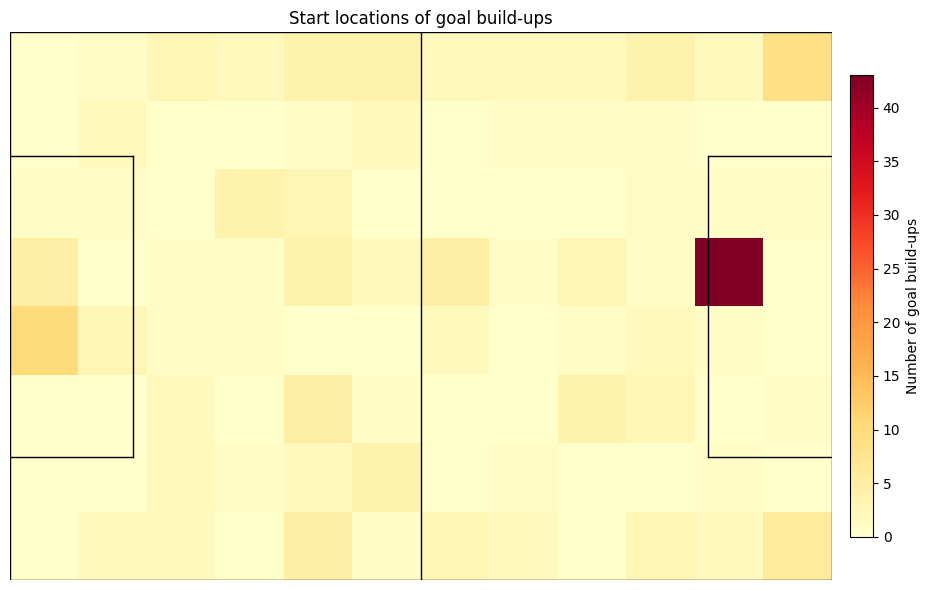

In [11]:
start_locations = buildups.dropna(subset=["start_x", "start_y"])

fig, ax = plt.subplots(figsize=(10, 6))

draw_pitch(ax)

heatmap = ax.hist2d(
    start_locations["start_x"],
    start_locations["start_y"],
    bins=[12, 8],
    range=[[0, 120], [0, 80]],
    cmap="YlOrRd"
)

ax.set_title("Start locations of goal build-ups")

fig.colorbar(
    heatmap[3],
    ax=ax,
    fraction=0.025,
    pad=0.02,
    label="Number of goal build-ups"
)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig05_start_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Exploratory Figure: Quick vs long start locations

This plot compares start locations for quick and long goal build-ups. It can be used as exploratory evidence, but only if the visual pattern is clearly readable.

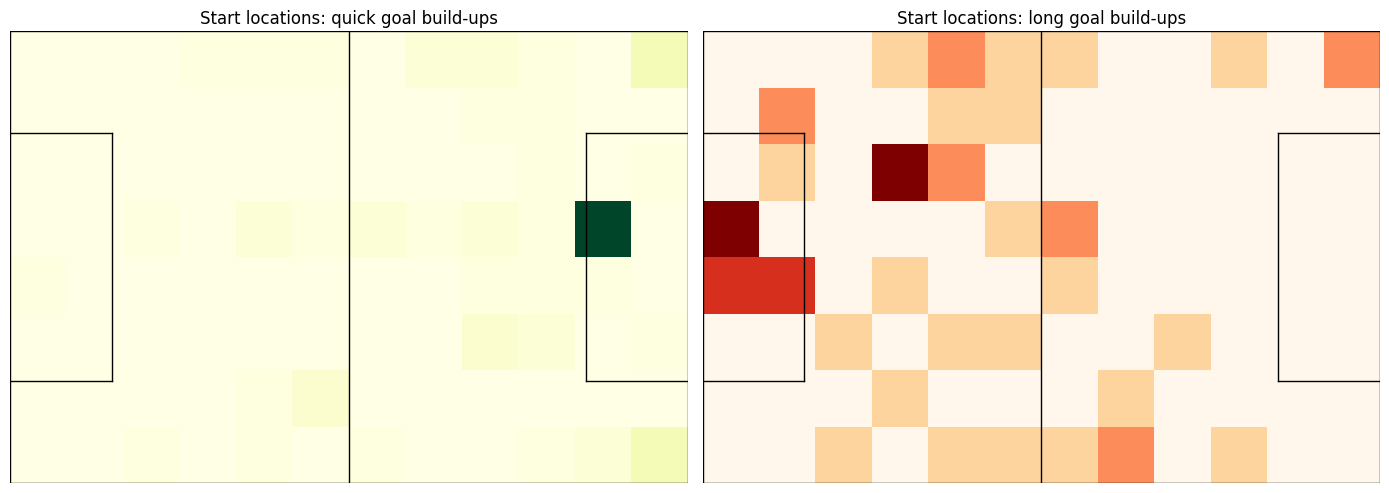

In [12]:
quick_starts = buildups[buildups["build_up_type"] == "Quick"].dropna(subset=["start_x", "start_y"])
long_starts = buildups[buildups["build_up_type"] == "Long"].dropna(subset=["start_x", "start_y"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

draw_pitch(axes[0])
axes[0].hist2d(
    quick_starts["start_x"],
    quick_starts["start_y"],
    bins=[12, 8],
    range=[[0, 120], [0, 80]],
    cmap="YlGn"
)
axes[0].set_title("Start locations: quick goal build-ups")

draw_pitch(axes[1])
axes[1].hist2d(
    long_starts["start_x"],
    long_starts["start_y"],
    bins=[12, 8],
    range=[[0, 120], [0, 80]],
    cmap="OrRd"
)
axes[1].set_title("Start locations: long goal build-ups")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig06_quick_vs_long_start_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

### Exploratory Figure: Zone-to-zone pass flows

The first version with all individual passes was too cluttered. This version groups the pitch into zones and shows only the most common zone-to-zone pass movements.

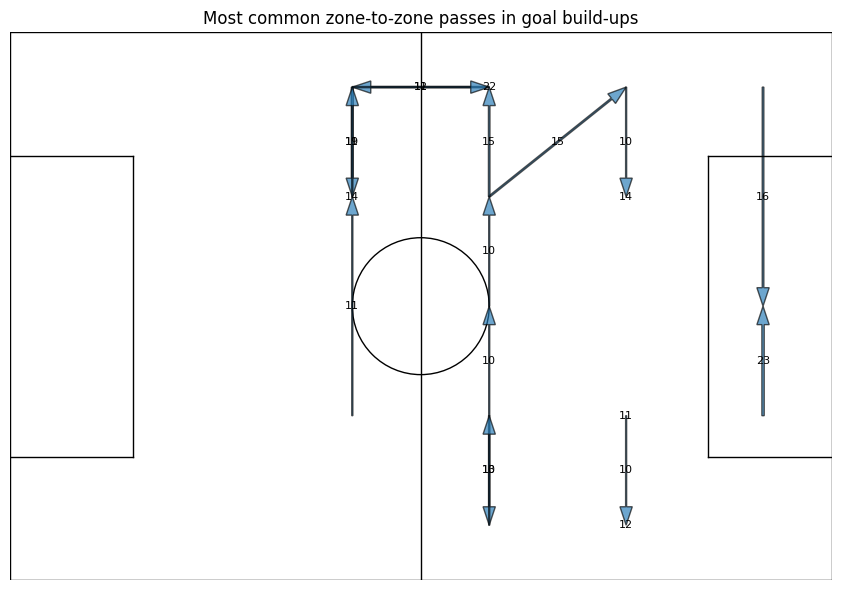

,start_x_bin,start_y_bin,end_x_bin,end_y_bin,count
283,5,3,5,2,23
158,3,0,3,0,22
94,2,0,2,1,19
270,5,0,5,2,16
175,3,1,4,0,15
171,3,1,3,0,15
106,2,1,2,1,14
228,4,1,4,1,14
197,3,3,3,4,13
261,4,4,4,4,12


In [13]:
pass_map_data = passes.dropna(subset=["x", "y", "end_x", "end_y"]).copy()

x_bins = [0, 20, 40, 60, 80, 100, 120]
y_bins = [0, 16, 32, 48, 64, 80]

pass_map_data["start_x_bin"] = pd.cut(
    pass_map_data["x"],
    bins=x_bins,
    labels=False,
    include_lowest=True
)

pass_map_data["start_y_bin"] = pd.cut(
    pass_map_data["y"],
    bins=y_bins,
    labels=False,
    include_lowest=True
)

pass_map_data["end_x_bin"] = pd.cut(
    pass_map_data["end_x"],
    bins=x_bins,
    labels=False,
    include_lowest=True
)

pass_map_data["end_y_bin"] = pd.cut(
    pass_map_data["end_y"],
    bins=y_bins,
    labels=False,
    include_lowest=True
)

pass_map_data = pass_map_data.dropna(
    subset=["start_x_bin", "start_y_bin", "end_x_bin", "end_y_bin"]
)

zone_flows = (
    pass_map_data.groupby(["start_x_bin", "start_y_bin", "end_x_bin", "end_y_bin"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)

def zone_center_x(x_bin):
    return 10 + x_bin * 20


def zone_center_y(y_bin):
    return 8 + y_bin * 16


fig, ax = plt.subplots(figsize=(10, 6))

draw_pitch(ax)

for _, row in zone_flows.iterrows():
    x1 = zone_center_x(int(row["start_x_bin"]))
    y1 = zone_center_y(int(row["start_y_bin"]))
    x2 = zone_center_x(int(row["end_x_bin"]))
    y2 = zone_center_y(int(row["end_y_bin"]))

    ax.arrow(
        x1,
        y1,
        x2 - x1,
        y2 - y1,
        length_includes_head=True,
        head_width=1.8,
        width=0.015 * row["count"],
        alpha=0.65
    )

    ax.text(
        (x1 + x2) / 2,
        (y1 + y2) / 2,
        str(int(row["count"])),
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title("Most common zone-to-zone passes in goal build-ups")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig07_zone_pass_flows.png", dpi=300, bbox_inches="tight")
plt.show()

display(zone_flows)

## 9. Team efficiency and tournament progress

Pass count alone does not explain team success. Therefore, I add team-level shot information and tournament stage information. This allows a comparison between goal build-up style, finishing efficiency and tournament progress.

In [14]:
TEAM_CONTEXT_FILE = PROCESSED_DIR / "team_tournament_context.csv"

def build_team_context(force_rebuild=False):
    if TEAM_CONTEXT_FILE.exists() and not force_rebuild:
        return pd.read_csv(TEAM_CONTEXT_FILE)

    matches = sb.matches(
        competition_id=COMPETITION_ID,
        season_id=SEASON_ID
    )

    stage_order = {
        "Group Stage": 1,
        "Round of 16": 2,
        "Quarter-finals": 3,
        "Semi-finals": 4,
        "3rd Place Final": 5,
        "Final": 6
    }

    all_shots = []
    all_stages = []

    for _, match in matches.reset_index(drop=True).iterrows():
        match_id = int(match["match_id"])
        home_team = match["home_team"]
        away_team = match["away_team"]
        stage = str(match.get("competition_stage"))

        all_stages.append({"team": home_team, "stage": stage})
        all_stages.append({"team": away_team, "stage": stage})

        try:
            events = sb.events(match_id=match_id)
        except Exception:
            continue

        if "type" not in events.columns:
            continue

        for col in ["team", "shot_outcome", "possession"]:
            if col not in events.columns:
                events[col] = np.nan

        shots_df = events[events["type"] == "Shot"].copy()

        for _, shot in shots_df.iterrows():
            all_shots.append(
                {
                    "team": shot["team"],
                    "shot_outcome": shot.get("shot_outcome"),
                    "possession": shot.get("possession")
                }
            )

    shots_table = pd.DataFrame(all_shots)
    stages_table = pd.DataFrame(all_stages)

    team_shots = (
        shots_table.groupby("team")
        .agg(
            shots=("team", "count"),
            shot_possessions=("possession", "nunique")
        )
        .reset_index()
    )

    goals_table = shots_table[
        shots_table["shot_outcome"].astype(str).str.lower() == "goal"
    ]

    team_goals = (
        goals_table.groupby("team")
        .size()
        .reset_index(name="goals")
    )

    team_stage = stages_table.copy()
    team_stage["stage_score"] = team_stage["stage"].map(stage_order).fillna(0)

    team_stage = (
        team_stage.sort_values("stage_score")
        .groupby("team")
        .tail(1)
        .reset_index(drop=True)
    )

    context = team_shots.merge(team_goals, on="team", how="left")
    context = context.merge(team_stage[["team", "stage", "stage_score"]], on="team", how="left")

    context["goals"] = context["goals"].fillna(0)
    context["conversion_rate"] = context["goals"] / context["shots"]
    context["goals_per_shot_possession"] = context["goals"] / context["shot_possessions"]

    context.to_csv(TEAM_CONTEXT_FILE, index=False)

    return context

team_context = build_team_context(force_rebuild=False)

display(team_context.sort_values("stage_score", ascending=False).head(10))

,team,shots,shot_possessions,goals,stage,stage_score,conversion_rate,goals_per_shot_possession
0,Argentina,110,83,23,Final,6,0.209091,0.277108
11,France,106,81,18,Final,6,0.169811,0.222222
7,Croatia,87,66,15,3rd Place Final,5,0.172414,0.227273
17,Morocco,66,53,9,3rd Place Final,5,0.136364,0.169811
18,Netherlands,48,40,13,Quarter-finals,3,0.270833,0.325000
10,England,63,53,13,Quarter-finals,3,0.206349,0.245283
3,Brazil,99,78,10,Quarter-finals,3,0.101010,0.128205
20,Portugal,66,52,12,Quarter-finals,3,0.181818,0.230769
27,Switzerland,37,32,5,Round of 16,2,0.135135,0.156250
26,Spain,51,45,9,Round of 16,2,0.176471,0.200000


## 10. Combined team analysis table

This table combines build-up information with finishing efficiency and tournament stage. It is the basis for the following team-level figures.

In [15]:
team_buildup = (
    buildups.groupby("team")
    .agg(
        goals_in_buildup_data=("build_up_id", "count"),
        avg_passes_before_goal=("passes_before_goal", "mean"),
        median_passes_before_goal=("passes_before_goal", "median"),
        avg_duration_seconds=("duration_seconds", "mean")
    )
    .reset_index()
)

team_analysis = team_buildup.merge(
    team_context,
    on="team",
    how="left"
)

team_analysis = team_analysis[team_analysis["goals_in_buildup_data"] >= 2].copy()

display(
    team_analysis.sort_values("stage_score", ascending=False)
)

,team,goals_in_buildup_data,avg_passes_before_goal,median_passes_before_goal,avg_duration_seconds,shots,shot_possessions,goals,stage,stage_score,conversion_rate,goals_per_shot_possession
0,Argentina,23,3.565217,0.0,11.304348,110,83,23,Final,6,0.209091,0.277108
11,France,18,6.500000,5.5,21.777778,106,81,18,Final,6,0.169811,0.222222
17,Morocco,9,3.000000,1.0,10.888889,66,53,9,3rd Place Final,5,0.136364,0.169811
7,Croatia,15,4.266667,1.0,13.066667,87,66,15,3rd Place Final,5,0.172414,0.227273
10,England,13,7.230769,3.0,21.615385,63,53,13,Quarter-finals,3,0.206349,0.245283
18,Netherlands,13,6.076923,6.0,20.461538,48,40,13,Quarter-finals,3,0.270833,0.325000
20,Portugal,12,5.083333,3.0,16.500000,66,52,12,Quarter-finals,3,0.181818,0.230769
3,Brazil,10,6.600000,6.0,22.500000,99,78,10,Quarter-finals,3,0.101010,0.128205
26,Spain,9,18.222222,23.0,57.666667,51,45,9,Round of 16,2,0.176471,0.200000
27,Switzerland,5,6.400000,5.0,20.600000,37,32,5,Round of 16,2,0.135135,0.156250


### Figure 5: Finishing efficiency and tournament progress

This figure checks whether teams with better finishing efficiency tended to progress further in the tournament. It shows association, not causation.

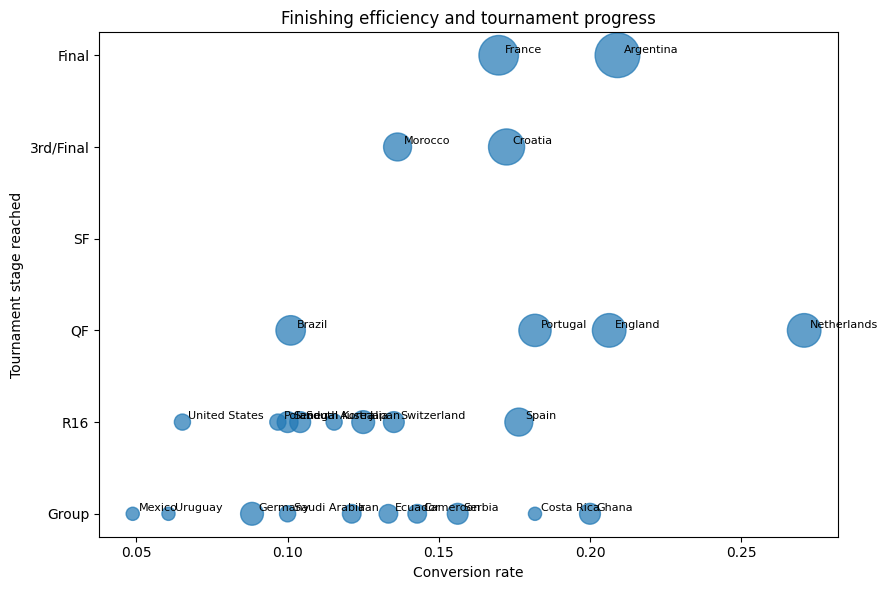

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    team_analysis["conversion_rate"],
    team_analysis["stage_score"],
    s=team_analysis["goals"] * 45,
    alpha=0.7
)

for _, row in team_analysis.iterrows():
    ax.text(
        row["conversion_rate"] + 0.002,
        row["stage_score"] + 0.03,
        row["team"],
        fontsize=8
    )

ax.set_title("Finishing efficiency and tournament progress")
ax.set_xlabel("Conversion rate")
ax.set_ylabel("Tournament stage reached")

ax.set_yticks([1, 2, 3, 4, 5, 6])
ax.set_yticklabels([
    "Group",
    "R16",
    "QF",
    "SF",
    "3rd/Final",
    "Final"
])

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig10_efficiency_vs_stage.png", dpi=300, bbox_inches="tight")
plt.show()

### Figure 6: Goal output and average passes before goal

This figure checks whether teams with more goals tended to score after shorter or longer build-ups. The point size represents tournament progress.

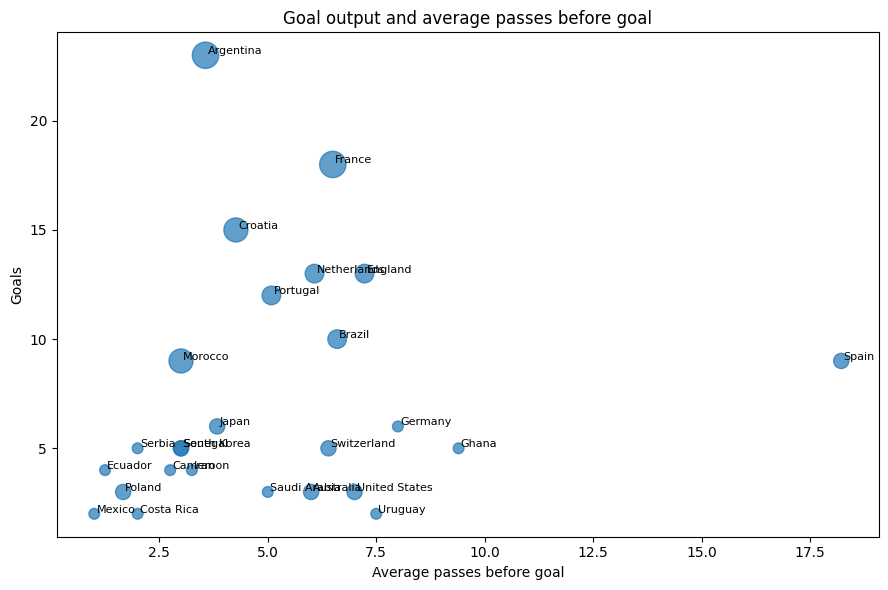

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    team_analysis["avg_passes_before_goal"],
    team_analysis["goals"],
    s=team_analysis["stage_score"] * 60,
    alpha=0.7
)

for _, row in team_analysis.iterrows():
    ax.text(
        row["avg_passes_before_goal"] + 0.05,
        row["goals"] + 0.05,
        row["team"],
        fontsize=8
    )

ax.set_title("Goal output and average passes before goal")
ax.set_xlabel("Average passes before goal")
ax.set_ylabel("Goals")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig11_goals_vs_avg_passes.png", dpi=300, bbox_inches="tight")
plt.show()

### Figure 7: Team build-up style and tournament progress

This figure combines average passes before goal, average build-up duration and tournament progress. It is one of the main summary figures because it connects playing style with tournament outcome.

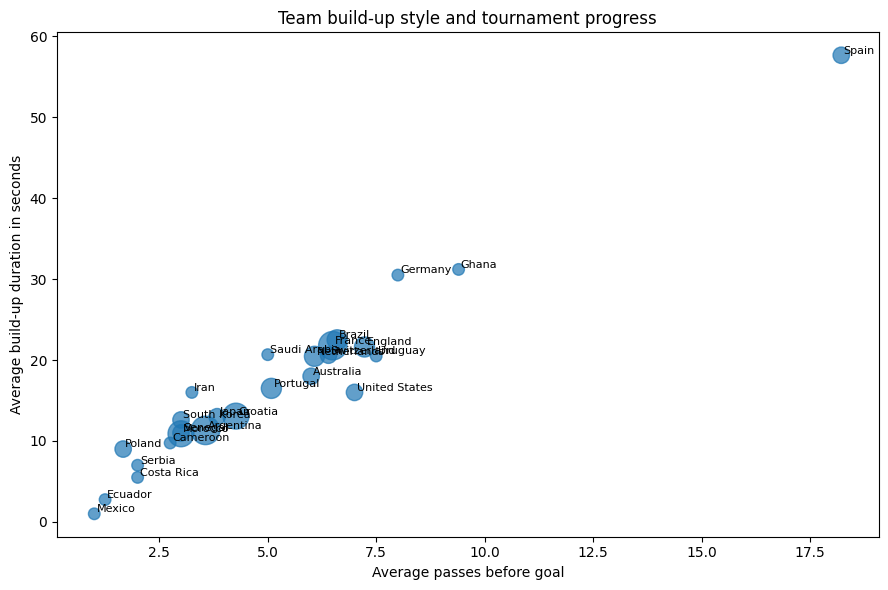

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    team_analysis["avg_passes_before_goal"],
    team_analysis["avg_duration_seconds"],
    s=team_analysis["stage_score"] * 70,
    alpha=0.7
)

for _, row in team_analysis.iterrows():
    ax.text(
        row["avg_passes_before_goal"] + 0.05,
        row["avg_duration_seconds"] + 0.2,
        row["team"],
        fontsize=8
    )

ax.set_title("Team build-up style and tournament progress")
ax.set_xlabel("Average passes before goal")
ax.set_ylabel("Average build-up duration in seconds")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig12_team_style_stage.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Spain case study

Spain is used as a case study because Spain is strongly associated with possession-based football. A Spanish goal with many passes is therefore a plausible example for showing a longer passing sequence before a goal.

In [19]:
spain_goals = buildups[buildups["team"] == "Spain"].copy()

display(
    spain_goals[
        ["build_up_id", "match_label", "goal_player", "goal_minute", "passes_before_goal", "duration_seconds"]
    ].sort_values("passes_before_goal", ascending=False)
)

,build_up_id,match_label,goal_player,goal_minute,passes_before_goal,duration_seconds
151,3857291_4,Spain vs Costa Rica,Ferrán Torres García,53,33,98
192,3857255_1,Japan vs Spain,Álvaro Borja Morata Martín,11,30,106
148,3857291_1,Spain vs Costa Rica,Daniel Olmo Carvajal,10,26,75
149,3857291_2,Spain vs Costa Rica,Marco Asensio Willemsen,20,26,79
154,3857291_7,Spain vs Costa Rica,Álvaro Borja Morata Martín,91,23,65
104,3857263_1,Spain vs Germany,Álvaro Borja Morata Martín,61,16,44
153,3857291_6,Spain vs Costa Rica,Carlos Soler Barragán,89,6,24
152,3857291_5,Spain vs Costa Rica,Pablo Martín Páez Gavira,73,4,28
150,3857291_3,Spain vs Costa Rica,Ferrán Torres García,30,0,0


### Figure 8: Spain goal build-up sequence

This figure shows one concrete Spanish goal build-up as a pass sequence. It is the clearest bridge from the static GDV analysis to a later interactive IVI version.

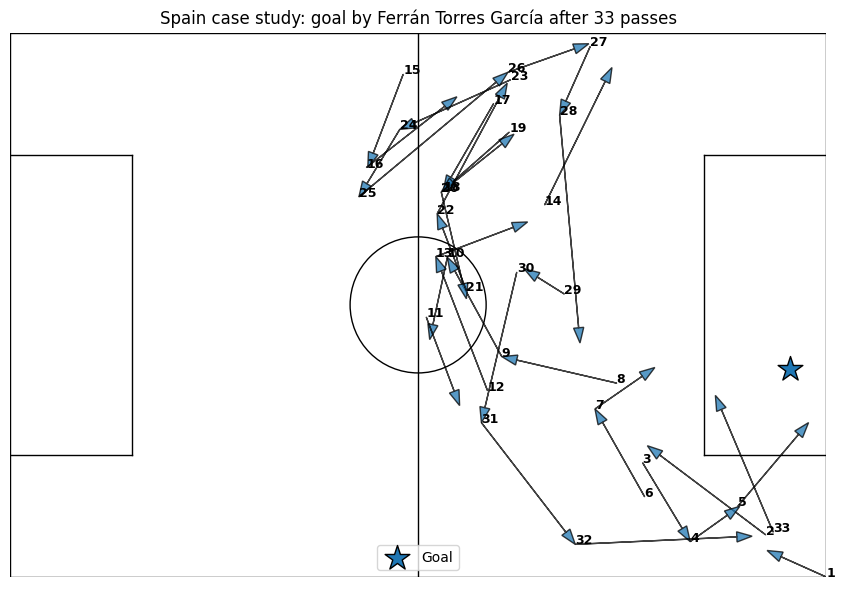

,pass_order,player,minute,second,x,y,end_x,end_y
729,1,Marco Asensio Willemsen,52,3,120.0,80.0,111.3,76.1
730,2,Daniel Olmo Carvajal,52,6,111.1,73.8,93.7,60.7
731,3,Pedro González López,52,8,93.0,63.2,100.0,74.8
732,4,Daniel Olmo Carvajal,52,10,100.0,74.8,107.3,69.6
733,5,Marco Asensio Willemsen,52,12,107.0,69.6,117.4,57.3
734,6,César Azpilicueta Tanco,52,26,93.3,68.2,86.0,55.3
735,7,Pedro González López,52,29,86.0,55.3,94.8,49.2
736,8,Marco Asensio Willemsen,52,32,89.2,51.5,72.3,47.6
737,9,Jordi Alba Ramos,52,35,72.3,47.6,64.3,33.0
738,10,Aymeric Laporte,52,37,64.3,33.0,61.7,45.1


In [20]:
case_goal = spain_goals.sort_values("passes_before_goal", ascending=False).iloc[0]
case_id = case_goal["build_up_id"]

case_passes = (
    passes[passes["build_up_id"] == case_id]
    .sort_values("pass_order")
)

fig, ax = plt.subplots(figsize=(10, 6))

draw_pitch(ax)

for _, p in case_passes.iterrows():
    ax.arrow(
        p["x"],
        p["y"],
        p["end_x"] - p["x"],
        p["end_y"] - p["y"],
        length_includes_head=True,
        head_width=1.5,
        alpha=0.75
    )

    ax.text(
        p["x"],
        p["y"],
        str(int(p["pass_order"])),
        fontsize=9,
        weight="bold"
    )

ax.scatter(
    [case_goal["goal_x"]],
    [case_goal["goal_y"]],
    marker="*",
    s=350,
    edgecolor="black",
    label="Goal"
)

ax.set_title(
    f"Spain case study: goal by {case_goal['goal_player']} after {case_goal['passes_before_goal']} passes"
)

ax.legend(loc="lower center")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "goal_fig13_spain_case_study.png", dpi=300, bbox_inches="tight")
plt.show()

display(case_passes[["pass_order", "player", "minute", "second", "x", "y", "end_x", "end_y"]])

## 12. Summary

This final section summarizes the main numerical results of the GDV analysis.

In [21]:
total_goals = len(buildups)
avg_passes = buildups["passes_before_goal"].mean()
median_passes = buildups["passes_before_goal"].median()
avg_duration = buildups["duration_seconds"].mean()

quick_goals = (buildups["build_up_type"] == "Quick").sum()
medium_goals = (buildups["build_up_type"] == "Medium").sum()
long_goals = (buildups["build_up_type"] == "Long").sum()

quick_share = quick_goals / total_goals
medium_share = medium_goals / total_goals
long_share = long_goals / total_goals

print("GDV summary")
print("-----------")
print(f"Analysed goals: {total_goals}")
print(f"Average passes before goal: {avg_passes:.2f}")
print(f"Median passes before goal: {median_passes:.2f}")
print(f"Average build-up duration: {avg_duration:.2f} seconds")
print(f"Quick goals: {quick_goals} ({quick_share:.1%})")
print(f"Medium goals: {medium_goals} ({medium_share:.1%})")
print(f"Long goals: {long_goals} ({long_share:.1%})")

print()
print("Saved figures:")
for path in sorted(FIGURE_DIR.glob("goal_fig*.png")):
    print(path)

GDV summary
-----------
Analysed goals: 195
Average passes before goal: 5.63
Median passes before goal: 4.00
Average build-up duration: 18.64 seconds
Quick goals: 97 (49.7%)
Medium goals: 51 (26.2%)
Long goals: 47 (24.1%)

Saved figures:
c:\Users\emirc\Football\reports\figures\goal_fig01_passes_before_goals.png
c:\Users\emirc\Football\reports\figures\goal_fig02_avg_passes_by_team.png
c:\Users\emirc\Football\reports\figures\goal_fig02_buildup_types.png
c:\Users\emirc\Football\reports\figures\goal_fig03_avg_passes_by_team.png
c:\Users\emirc\Football\reports\figures\goal_fig03_start_heatmap.png
c:\Users\emirc\Football\reports\figures\goal_fig04_pass_flow_map.png
c:\Users\emirc\Football\reports\figures\goal_fig04_passes_vs_duration.png
c:\Users\emirc\Football\reports\figures\goal_fig04_zone_pass_flows.png
c:\Users\emirc\Football\reports\figures\goal_fig05_case_study_sequence.png
c:\Users\emirc\Football\reports\figures\goal_fig05_start_heatmap.png
c:\Users\emirc\Football\reports\figures\goa

## 13. Design reflection

The analysis started with basic distribution and spatial plots. The heatmaps were useful for exploration, but they were not strong enough as the main final visualizations because the spatial pattern was difficult to interpret without a baseline of non-goal attacks.

For the final GDV story, the strongest figures are the distribution of passes before goals, the quick/medium/long build-up categories, the passes-versus-duration relationship, the team efficiency plot, the team style plot, and the Spain case study.

This supports the visualization pipeline: explore, design, evaluate critically, iterate, and communicate.

## 14. Limitations

The analysis uses event data, not tracking data. Therefore, it shows ball actions but not the movement of all players.

The possession ID is used as an approximation for the attacking sequence before a goal. This is reasonable for the project, but it is not a complete tactical reconstruction.

Finishing efficiency and tournament progress are compared descriptively. The figures show possible patterns, but they do not prove causality.

Teams with few goals can have unstable averages. For team-level comparisons, teams with at least two goals are used to reduce the impact of single-goal outliers.